# GRUPO 43 — Entrega 7: techo real del problema y última mejora del *stacking*

**Contexto.** La entrega 6 obtuvo 0.8989 en el *leaderboard* público de Kaggle, sin mejora frente a la 5. El objetivo de esta entrega era pasar 0.90 y, en lo posible, llegar a 0.92.

**Resultado, dicho de entrada:**

1. **0.92 no es alcanzable en promedio por ningún modelo** con este conjunto de datos. Con un detector mejorado medimos que el **17.8 %** de `eval.csv` son reseñas cuya etiqueta es aleatoria respecto al texto (≈ 50 % de acierto con cualquier método). Eso fija un **techo esperado de ≈ 0.911**, aunque todo lo demás se acierte perfecto.
2. **Nuestro modelo ya está pegado a ese techo.** En las reseñas predecibles, el *stacking* de la entrega 6 acierta el **98.9 %**. Esta entrega agrega una vista de texto nueva, la **última cláusula con opinión**, que reduce los errores predecibles en ≈ 11 %. Es una mejora real, pero equivale a ≈ 0.1 puntos.
3. **El puntaje público de Kaggle tiene un ruido de ±0.7–0.9 puntos**, que viene de cómo caen las monedas al aire del grupo aleatorio en el subconjunto público. Un modelo con la calidad del nuestro puede sacar cualquier valor entre ≈ 0.89 y ≈ 0.92 según la suerte de la partición (sección 5). Por eso 0.8989 no indica que el modelo sea peor, y un 0.92 de otro grupo no indica que el suyo sea mejor.

**Reglas (Parte 1):** sin redes neuronales, transformers ni *embeddings*; solo BoW, TF‑IDF y n‑gramas, con clasificadores de scikit-learn (`LogisticRegression`, `MultinomialNB`, `RandomForestClassifier`). `eval.csv` solo se usa para predecir. En las secciones 2 y 5 únicamente se **cuentan** frases de su texto, sin usar etiquetas y sin entrenar nada con él.

## 1. Código reutilizado de la entrega 6

Limpieza (con normalización de letras repetidas), cláusulas, conectores, listas de diagnóstico, modelos base, `PolaridadClausulas2` y `StackingPolaridad2`, sin cambios.

In [1]:
import warnings
warnings.filterwarnings("ignore")
import re, unicodedata
from collections import Counter
from contextlib import contextmanager
from pathlib import Path
import numpy as np, pandas as pd
import matplotlib.pyplot as plt
import joblib
from sklearn.base import BaseEstimator, TransformerMixin, ClassifierMixin
from sklearn.model_selection import train_test_split, StratifiedKFold, cross_val_predict, cross_val_score
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer
from sklearn.preprocessing import FunctionTransformer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.naive_bayes import MultinomialNB
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay

RANDOM_STATE = 42
ORDER = ["negativo", "neutral", "positivo"]
COLORS = {"negativo": "#E45756", "neutral": "#9D9D9D", "positivo": "#54A24B"}
DATA_DIR = Path("../data")
Path("models").mkdir(exist_ok=True)

train_df = pd.read_csv(DATA_DIR / "train.csv")
eval_df = pd.read_csv(DATA_DIR / "eval.csv")
sample_sub = pd.read_csv(DATA_DIR / "sample_submission.csv")
assert eval_df["id"].equals(sample_sub["id"])
print(train_df.shape, eval_df.shape)

(12000, 3) (3000, 2)


In [2]:
NORMALIZAR_REPETIDAS = True

def quitar_tildes(t):
    t = unicodedata.normalize("NFKD", t)
    return "".join(c for c in t if not unicodedata.combining(c))

def limpiar_texto(t):
    t = quitar_tildes(str(t).lower())
    t = re.sub(r"[^a-zñ\s]", " ", t)
    if NORMALIZAR_REPETIDAS:
        t = re.sub(r"([a-zñ])\1+", r"\1", t)   # "conffiable" -> "confiable"
    return re.sub(r"\s+", " ", t).strip()

@contextmanager
def limpieza_entrega5():
    # Reproduce la limpieza de la entrega 5 (sin colapsar letras) dentro de un bloque `with`.
    global NORMALIZAR_REPETIDAS
    NORMALIZAR_REPETIDAS = False
    try:
        yield
    finally:
        NORMALIZAR_REPETIDAS = True

def separar_clausulas(t):
    t = re.sub(r"\b(pero|aunque|sin embargo)\b", r". \1", str(t), flags=re.I)
    c = [limpiar_texto(p) for p in re.split(r"[.!?;]+", t)]
    c = [x for x in c if x]
    return c if c else [""]

CONECTORES = ["eso si", "aun asi", "por otro lado", "la verdad", "por cierto", "de paso", "con todo", "ademas",
              "al final", "a fin de cuentas", "ahora", "pero", "aunque", "sin embargo", "en fin", "para mi",
              "en mi opinion", "para ser sincero", "la verdad sea dicha", "hay de todo", "para gustos", "sigo con dudas"]
_ORD = sorted(CONECTORES, key=len, reverse=True)

def conector(c):
    for k in _ORD:
        if c == k or c.startswith(k + " "):
            return CONECTORES.index(k)
    return -1

CIERRES = ["cada quien", "para gustos", "sigo con dudas", "ni fu ni fa", "a criterio", "hay de todo", "no sabria bien",
           "sopesalo", "no me decido", "ni lo mejor ni lo peor", "ni tan bueno ni tan malo", "ahi lo dejo",
           "sentimientos encontrados"]

def es_cierre(c):
    return any(k in c for k in CIERRES)

In [3]:
_norm = lambda xs: [limpiar_texto(x) for x in xs]
ADJ_POS = set(_norm(
    "resistente eficiente impecable confiable funcional veloz sobresaliente potente decente superior notable formidable "
    "excelente espectacular durable agradable cumplidor cumplidora practica practico buenisima buenisimo rapidisima "
    "rapidisimo comoda comodo comodisima comodisimo buena bueno redonda redondo optimo optima precisa preciso correcta "
    "correcto ligera ligero solida solido robusta robusto estupenda estupendo completa completo nitida nitido logrado "
    "lograda fiable".split()))
ADJ_NEG = set(_norm(
    "terrible decepcionante torpe pobre debil deficiente corriente endeble mediocre desagradable inestable fragil "
    "inconsistente olvidable incumplidor incumplidora ruidosa ruidoso delicada delicado imprecisa impreciso lentisima "
    "lentisimo chapucera chapucero pesima pesimo malisima malisimo ordinaria ordinario floja flojo incomoda incomodo "
    "defectuosa defectuoso limitada limitado aparatosa aparatoso basica basico".split()))
FRASES_NEG = _norm(["tire el dinero", "decepciono", "error de compra", "ni regalado", "arrepiento", "arrepentido",
                    "una estrella", "una sola estrella", "dolor de cabeza", "harto", "muy molesto", "defraudo todas",
                    "no vale lo que cuesta", "para nada lo que esperaba", "queda muy corto", "queda corto",
                    "tener problemas", "debajo de la media", "no me convence", "recomiendo a nadie", "no me gusto",
                    "dano antes", "funciona bastante mal", "no me termina de gustar"])
FRASES_POS = _norm(["todas mis expectativas", "todo un acierto", "valio la pena", "vale totalmente la pena",
                    "de maravilla", "me encanto", "feliz", "ojos cerrados", "cinco estrellas", "ni una sola queja",
                    "me alegra", "tal como esperaba", "de sobra", "encantado", "vida mas facil", "encima de la media",
                    "lo que estaba buscando", "sin pensarlo", "para bien", "ninguna queja", "cero quejas", "contento"])
VERBO = r"(?:se mantuvo|luce|se ve|me resulto ser|me resulto|resulto ser|resulto|termino siendo|se sintio|me parecio|quedo|salio|me salio|es|esta|fue)"
RX_ADJ = re.compile(VERBO + r"\s+((?:muy|bastante|algo|un poco|demasiado|poco|mal|bien)\s+|de (?:mala|buena) )?([a-zñ]+)")

def signo_adjetivo(c):
    s = 0
    for m in RX_ADJ.finditer(c):
        mod, w = (m.group(1) or "").strip(), m.group(2)
        if mod in ("de mala", "de buena") and w == "calidad":
            s += 1 if mod == "de buena" else -1
        elif w in ADJ_POS:
            s += -1 if mod in ("poco", "mal") else 1
        elif w in ADJ_NEG:
            s -= 1
        elif w in ("hecha", "hecho", "terminada", "terminado", "construida", "construido") and mod in ("mal", "bien"):
            s += 1 if mod == "bien" else -1
    return int(np.sign(s))

def signo_frase(c):
    return int(np.sign(sum(k in c for k in FRASES_POS) - sum(k in c for k in FRASES_NEG)))

def es_mixta_frases(texto):
    # Reseña con al menos dos frases hechas de polaridad opuesta (no usa la etiqueta).
    return len({signo_frase(c) for c in separar_clausulas(texto)} - {0}) > 1

def grupo(texto, etiqueta):
    if etiqueta == "neutral":
        return "neutral"
    return "mixta frases hechas" if es_mixta_frases(texto) else "determinista"

In [4]:
def construir_vistas(textos):
    textos = pd.Series(textos).astype(str)
    return pd.DataFrame({"completo": textos.map(limpiar_texto).values,
                         "ultima_clausula": textos.map(lambda t: separar_clausulas(t)[-1]).values})

def vistas_texto(vectorizador_completo, vectorizador_ultima):
    return Pipeline([("vistas", FunctionTransformer(construir_vistas)),
                     ("vec", ColumnTransformer([("completo", vectorizador_completo, "completo"),
                                                ("ultima", vectorizador_ultima, "ultima_clausula")]))])

def modelo_lr(C=3):
    return Pipeline([("texto", vistas_texto(TfidfVectorizer(min_df=2, sublinear_tf=True, ngram_range=(1, 2)),
                                            TfidfVectorizer(min_df=2, sublinear_tf=True))),
                     ("clf", LogisticRegression(C=C, max_iter=4000, random_state=42))])

def modelo_nb(alpha=0.5):
    return Pipeline([("texto", vistas_texto(CountVectorizer(min_df=2, binary=True, ngram_range=(1, 2)),
                                            CountVectorizer(min_df=2, binary=True))),
                     ("clf", MultinomialNB(alpha=alpha))])

In [5]:
class PolaridadClausulas(BaseEstimator, TransformerMixin):
    # Entrega 5 (sin cambios).
    def __init__(self, n_posiciones=4, n_folds=5, random_state=42):
        self.n_posiciones = n_posiciones; self.n_folds = n_folds; self.random_state = random_state

    @staticmethod
    def _log_ratio(vec, textos, ma, mb):
        X = vec.transform(textos)
        a = np.asarray(X[ma].sum(0)).ravel() + 1
        b = np.asarray(X[mb].sum(0)).ravel() + 1
        return np.log(a / a.sum()) - np.log(b / b.sum())

    def _aprender(self, cl, y):
        y = np.asarray(y)
        ultimas = [c[-1] for c in cl]; completos = [" ".join(c) for c in cl]
        vp = CountVectorizer(binary=True, min_df=2).fit(ultimas)
        vo = CountVectorizer(binary=True, min_df=2).fit(completos)
        return vp, self._log_ratio(vp, ultimas, y == "positivo", y == "negativo"), \
               vo, self._log_ratio(vo, completos, y != "neutral", y == "neutral")

    def _features(self, cl, pesos):
        vp, wp, vo, wo = pesos
        filas = []
        for c in cl:
            pol = vp.transform(c) @ wp; op = vo.transform(c) @ wo
            f = []
            for k in range(1, self.n_posiciones + 1):
                f += [pol[-k], op[-k], conector(c[-k])] if len(c) >= k else [0.0, -99.0, -2]
            j = np.where(op > 0)[0]
            f += [pol[j[-1]] if len(j) else 0.0, conector(c[j[-1]]) if len(j) else -2,
                  pol[j[-2]] if len(j) > 1 else 0.0, conector(c[j[-2]]) if len(j) > 1 else -2,
                  op.max(), op.sum(), pol.sum(), len(c), len(j)]
            filas.append(f)
        return np.array(filas, dtype=float)

    def nombres(self):
        n = []
        for k in range(self.n_posiciones):
            n += [f"pol_ult-{k}", f"op_ult-{k}", f"con_ult-{k}"]
        return n + ["pol_ult_opinion", "con_ult_opinion", "pol_penult_opinion", "con_penult_opinion",
                    "op_max", "op_total", "pol_total", "n_clausulas", "n_con_opinion"]

    def fit(self, X, y):
        self.pesos_ = self._aprender([separar_clausulas(t) for t in X], y); return self

    def transform(self, X):
        return self._features([separar_clausulas(t) for t in X], self.pesos_)

    def fit_transform(self, X, y):
        cl = [separar_clausulas(t) for t in X]; y = np.asarray(y)
        F = np.zeros((len(cl), len(self.nombres())))
        for i1, i2 in StratifiedKFold(self.n_folds, shuffle=True, random_state=self.random_state).split(cl, y):
            F[i2] = self._features([cl[i] for i in i2], self._aprender([cl[i] for i in i1], y[i1]))
        self.pesos_ = self._aprender(cl, y)
        return F


class PolaridadClausulas2(PolaridadClausulas):
    # Entrega 6: léxico con bigramas sin cierres, palabra más polar y última cláusula fuertemente polar.
    def __init__(self, n_posiciones=4, n_folds=5, random_state=42, kappas=(2.0, 3.0)):
        super().__init__(n_posiciones, n_folds, random_state)
        self.kappas = kappas

    def _aprender(self, cl, y):
        y = np.asarray(y)
        ultimas = [c[-1] for c in cl]; completos = [" ".join(c) for c in cl]
        ok = np.array([not es_cierre(u) for u in ultimas])   # los cierres ambivalentes no enseñan polaridad
        vp = CountVectorizer(binary=True, min_df=2, ngram_range=(1, 2)).fit([u for u, k in zip(ultimas, ok) if k])
        vo = CountVectorizer(binary=True, min_df=2).fit(completos)
        return vp, self._log_ratio(vp, ultimas, (y == "positivo") & ok, (y == "negativo") & ok), \
               vo, self._log_ratio(vo, completos, y != "neutral", y == "neutral")

    @staticmethod
    def _peso_maximo(Xc, wp):
        # Para cada cláusula (fila), el peso con mayor valor absoluto entre sus palabras.
        pmax = np.zeros(Xc.shape[0])
        for i in range(Xc.shape[0]):
            idx = Xc.indices[Xc.indptr[i]:Xc.indptr[i + 1]]
            if len(idx):
                pmax[i] = wp[idx[np.abs(wp[idx]).argmax()]]
        return pmax

    def _features(self, cl, pesos):
        vp, wp, vo, wo = pesos
        filas = []
        for c in cl:
            Xc = vp.transform(c); pol = Xc @ wp; op = vo.transform(c) @ wo
            pmax = self._peso_maximo(Xc, wp)
            f = []
            for k in range(1, self.n_posiciones + 1):
                f += [pol[-k], op[-k], pmax[-k], conector(c[-k])] if len(c) >= k else [0.0, -99.0, 0.0, -2]
            j = np.where(op > 0)[0]
            f += [pol[j[-1]] if len(j) else 0.0, conector(c[j[-1]]) if len(j) else -2,
                  pol[j[-2]] if len(j) > 1 else 0.0, conector(c[j[-2]]) if len(j) > 1 else -2]
            for kappa in self.kappas:
                jj = np.where(np.abs(pmax) > kappa)[0]
                f += [pol[jj[-1]] if len(jj) else 0.0, pmax[jj[-1]] if len(jj) else 0.0,
                      conector(c[jj[-1]]) if len(jj) else -2, len(c) - 1 - jj[-1] if len(jj) else -1,
                      pol[jj[0]] if len(jj) else 0.0, len(jj)]
            f += [op.max(), op.sum(), pol.sum(), len(c), len(j), float(es_cierre(c[-1]))]
            filas.append(f)
        return np.array(filas, dtype=float)

    def nombres(self):
        n = []
        for k in range(self.n_posiciones):
            n += [f"pol_ult-{k}", f"op_ult-{k}", f"pmax_ult-{k}", f"con_ult-{k}"]
        n += ["pol_ult_opinion", "con_ult_opinion", "pol_penult_opinion", "con_penult_opinion"]
        for kappa in self.kappas:
            s = f"{kappa:g}"
            n += [f"pol_fuerte{s}", f"pmax_fuerte{s}", f"con_fuerte{s}", f"dist_fuerte{s}",
                  f"pol_prim_fuerte{s}", f"n_fuerte{s}"]
        return n + ["op_max", "op_total", "pol_total", "n_clausulas", "n_con_opinion", "cierre_ambivalente"]


def modelo_rf(leaf=3):
    return Pipeline([("polaridad", PolaridadClausulas2(random_state=42)),
                     ("clf", RandomForestClassifier(n_estimators=500, min_samples_leaf=leaf, n_jobs=-1, random_state=42))])

In [6]:
class StackingPolaridad(BaseEstimator, ClassifierMixin):
    # Nivel 1: LR (TF-IDF) y NB (BoW) -> probabilidades out-of-fold; variables de polaridad out-of-fold.
    # Nivel 2: Random Forest sobre [variables de polaridad + probabilidades LR + probabilidades NB].
    def __init__(self, C_lr=3, alpha_nb=0.5, leaf_meta=3, n_folds=5, random_state=42):
        self.C_lr = C_lr; self.alpha_nb = alpha_nb; self.leaf_meta = leaf_meta
        self.n_folds = n_folds; self.random_state = random_state

    def _polaridad(self):
        return PolaridadClausulas(n_folds=self.n_folds, random_state=self.random_state)

    def _meta_X(self, F, P_lr, P_nb):
        return np.hstack([F, P_lr, P_nb])

    def fit(self, X, y):
        X = pd.Series(X).reset_index(drop=True); y = np.asarray(y)
        cv = StratifiedKFold(self.n_folds, shuffle=True, random_state=self.random_state)
        self.lr_ = modelo_lr(self.C_lr); self.nb_ = modelo_nb(self.alpha_nb)
        P_lr = cross_val_predict(self.lr_, X, y, cv=cv, method="predict_proba")
        P_nb = cross_val_predict(self.nb_, X, y, cv=cv, method="predict_proba")
        self.pol_ = self._polaridad()
        F = self.pol_.fit_transform(X, y)
        self.lr_.fit(X, y); self.nb_.fit(X, y)
        self.X_meta_train_ = self._meta_X(F, P_lr, P_nb)
        self.meta_ = RandomForestClassifier(n_estimators=500, min_samples_leaf=self.leaf_meta, n_jobs=-1,
                                            random_state=self.random_state).fit(self.X_meta_train_, y)
        self.classes_ = self.meta_.classes_
        return self

    def meta_features(self, X):
        X = pd.Series(X)
        return self._meta_X(self.pol_.transform(X), self.lr_.predict_proba(X), self.nb_.predict_proba(X))

    def nombres_meta(self):
        return self.pol_.nombres() + [f"p_lr_{c}" for c in self.lr_.classes_] + [f"p_nb_{c}" for c in self.nb_.classes_]

    def predict_proba(self, X):
        return self.meta_.predict_proba(self.meta_features(X))

    def predict(self, X):
        return self.classes_[self.predict_proba(X).argmax(1)]


class StackingPolaridad2(StackingPolaridad):
    # Entrega 6: mismo ensamble con las variables de PolaridadClausulas2.
    def _polaridad(self):
        return PolaridadClausulas2(n_folds=self.n_folds, random_state=self.random_state)

## 2. Diagnóstico mejorado: ¿cuántas reseñas son aleatorias?

La entrega 6 estimó que ≈ 15 % de las reseñas son mixtas con frases hechas, y que en ellas la etiqueta es una moneda al aire. Al revisar los errores que quedaban "en la parte predecible" encontramos que **casi todos eran reseñas de ese mismo grupo que las listas no detectaban**:

- *"defraudó **todas mis expectativas**"* se contaba como positiva, porque contiene la frase positiva *"todas mis expectativas"*;
- dos frases opuestas en **la misma cláusula** (*"me arrepiento de X **y** terminé feliz con Y"*) se cancelaban y la reseña no se marcaba como mixta;
- faltaban frases como *"por debajo de la media"*, *"fue una mala elección"* o *"me sorprendió para bien"*.

El detector v2 busca **cada aparición** de cada frase en orden. Primero las negativas, que se borran del texto para que no se relean como positivas. Marca una reseña como **aleatoria** si tiene frases de ambos signos y ninguna opinión de tipo adjetivo (*"se mantuvo resistente"*). **Este detector no es una variable del modelo**: solo sirve para medir.

In [7]:
FRASES_NEG_V2 = FRASES_NEG + _norm(["defraudo todas mis expectativas", "por debajo de la media", "mala eleccion",
                                     "dejo arrepentido", "no es para nada", "fue un error", "no lo recomiendo",
                                     "no la recomiendo", "no le recomiendo", "no volveria", "una estrella", "no vale"])
FRASES_POS_V2 = FRASES_POS + _norm(["termino gustando", "me sorprendio para bien", "respondio tal como esperaba",
                                     "recomiendo", "volveria a comprar", "cinco estrellas", "vale la pena",
                                     "me dejo contento", "me tiene contento", "cumple de sobra", "me gusto"])

def ocurrencias_frases(texto):
    # Lista ordenada de (posición, signo) de cada frase hecha. Las negativas se buscan primero y se borran.
    s = limpiar_texto(texto); occ = []
    for lista, signo in [(sorted(set(FRASES_NEG_V2), key=len, reverse=True), -1),
                         (sorted(set(FRASES_POS_V2), key=len, reverse=True), 1)]:
        for f in lista:
            for m in re.finditer(r"\b" + re.escape(f) + r"\b", s):
                occ.append((m.start(), signo)); s = s[:m.start()] + "#" * len(f) + s[m.end():]
    return sorted(occ)

def grupo_v2(texto, etiqueta=None):
    if etiqueta == "neutral":
        return "neutral"
    signos = {s for _, s in ocurrencias_frases(texto)}
    tiene_adjetivo = any(signo_adjetivo(c) != 0 for c in separar_clausulas(texto))
    return "aleatorio" if len(signos) > 1 and not tiene_adjetivo else "predecible"

G_train = np.array([grupo_v2(t, l) for t, l in zip(train_df["text"], train_df["label"])])
G_eval = np.array([grupo_v2(t) for t in eval_df["text"]])   # sin etiquetas: solo cuenta frases

resumir = lambda G: pd.Series(np.where(G == "aleatorio", "aleatorio", "predecible o neutral")).value_counts(normalize=True)
tabla = pd.DataFrame({"train.csv": resumir(G_train), "eval.csv": resumir(G_eval)})
print(f"Neutrales detectadas como aleatorias en train: {np.mean([grupo_v2(t) == 'aleatorio' for t in train_df.loc[train_df.label == 'neutral', 'text']]):.1%}")
frac_eval = (G_eval == "aleatorio").mean()
print(f"Reseñas aleatorias -> train: {(G_train == 'aleatorio').mean():.1%} | eval: {frac_eval:.1%}")
print(f"Techo esperado en eval (todo lo demás perfecto): 1 - 0.5 x {frac_eval:.3f} = {1 - 0.5 * frac_eval:.3f}")
tabla.round(3)

Neutrales detectadas como aleatorias en train: 0.0%
Reseñas aleatorias -> train: 17.2% | eval: 17.7%
Techo esperado en eval (todo lo demás perfecto): 1 - 0.5 x 0.177 = 0.911


,train.csv,eval.csv
predecible o neutral,0.828,0.823
aleatorio,0.172,0.177


### 2.1 Control: ¿de verdad es aleatorio?

Si existiera una regla oculta en ese grupo, algún método debería superar claramente el 50 %. Probamos la regla de "gana la última frase", la de "gana la primera", TF‑IDF + regresión logística y n‑gramas de caracteres, todos con validación cruzada de 5 *folds* **solo** sobre ese grupo. Durante el desarrollo también probamos un Random Forest con variables de identidad de cada frase, su posición, el conector, el aspecto, la longitud y la distancia al final: dio 0.52.

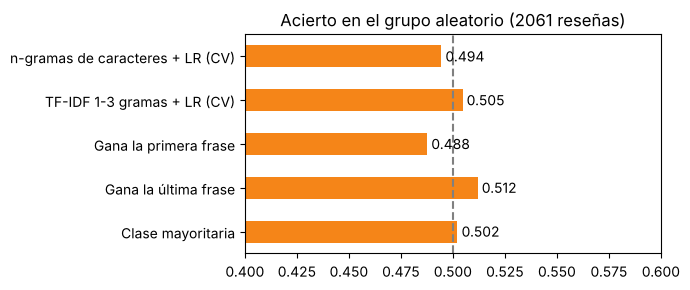

In [8]:
m_al = G_train == "aleatorio"
X_al, y_al = train_df.loc[m_al, "text"], train_df.loc[m_al, "label"]
y_bin = np.where(y_al == "positivo", 1, -1)
occ = [ocurrencias_frases(t) for t in X_al]
cv5 = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
lr_w = Pipeline([("v", TfidfVectorizer(preprocessor=limpiar_texto, ngram_range=(1, 3), min_df=2, sublinear_tf=True)),
                 ("c", LogisticRegression(C=1, max_iter=5000))])
lr_c = Pipeline([("v", TfidfVectorizer(preprocessor=limpiar_texto, analyzer="char_wb", ngram_range=(2, 5), min_df=2, sublinear_tf=True)),
                 ("c", LogisticRegression(C=1, max_iter=5000))])
prueba = pd.Series({
    "Clase mayoritaria": y_al.value_counts(normalize=True).max(),
    "Gana la última frase": np.mean([o[-1][1] for o in occ] == y_bin),
    "Gana la primera frase": np.mean([o[0][1] for o in occ] == y_bin),
    "TF-IDF 1-3 gramas + LR (CV)": cross_val_score(lr_w, X_al, y_al, cv=cv5).mean(),
    "n-gramas de caracteres + LR (CV)": cross_val_score(lr_c, X_al, y_al, cv=cv5).mean(),
})
ax = prueba.plot(kind="barh", figsize=(7, 3), color="#F58518", xlim=(0.4, 0.6))
ax.axvline(0.5, ls="--", color="gray"); ax.set_title(f"Acierto en el grupo aleatorio ({m_al.sum()} reseñas)")
for i, v in enumerate(prueba.values):
    ax.text(v + 0.002, i, f"{v:.3f}", va="center")
plt.tight_layout(); plt.show()

**Qué sale:** todos los métodos quedan en 0.49–0.52. Con ≈ 2.000 reseñas, el error estándar de una proporción es de ≈ 1.1 puntos, así que nada se separa del azar. **Este grupo es ruido irreducible**, y la única forma de "ganar" en él es la suerte.

## 3. Mejora del modelo: vista "última cláusula con opinión"

En las reseñas predecibles la clase la decide **la última cláusula que contiene una opinión**. La entrega 6 le daba a la regresión logística la **última cláusula**, que a veces es relleno con palabras que parecen opinión: *"…me arrepiento del botón. Aun así sigo revisando, porque el envío llegó rápido y venía **bien empacado**"*.

`VistaOpiniones` aprende, con conteos BoW de unigramas y bigramas, qué palabras distinguen las cláusulas de reseñas con opinión de las cláusulas de reseñas neutrales. Con ese puntaje busca la última cláusula con opinión y la anterior. Se ajusta dentro del `Pipeline`, así que en validación cruzada solo ve los datos de entrenamiento de cada *fold*.

In [9]:
class VistaOpiniones(BaseEstimator, TransformerMixin):
    def __init__(self, umbral=0.0):
        self.umbral = umbral

    def fit(self, X, y):
        cl = [separar_clausulas(t) for t in X]; y = np.asarray(y)
        textos = [c for cc in cl for c in cc]
        con_opinion = np.array([yy != "neutral" for cc, yy in zip(cl, y) for _ in cc])
        self.vec_ = CountVectorizer(binary=True, min_df=3, ngram_range=(1, 2)).fit(textos)
        Xc = self.vec_.transform(textos)
        a = np.asarray(Xc[con_opinion].sum(0)).ravel() + 1; b = np.asarray(Xc[~con_opinion].sum(0)).ravel() + 1
        self.w_ = np.log(a / a.sum()) - np.log(b / b.sum())   # > 0: palabra típica de opinión
        return self

    def puntaje(self, clausulas):
        return np.asarray(self.vec_.transform(clausulas) @ self.w_).ravel()

    def transform(self, X):
        filas = []
        for t in X:
            cc = separar_clausulas(t); j = np.where(self.puntaje(cc) > self.umbral)[0]
            filas.append({"completo": limpiar_texto(t), "ult_op": cc[j[-1]] if len(j) else ""})
        return pd.DataFrame(filas)

def modelo_lr_op(C=3):
    return Pipeline([("vista", VistaOpiniones()),
                     ("vec", ColumnTransformer([("completo", TfidfVectorizer(min_df=2, sublinear_tf=True, ngram_range=(1, 2)), "completo"),
                                                ("ult_op", TfidfVectorizer(min_df=2, sublinear_tf=True, ngram_range=(1, 2)), "ult_op")])),
                     ("clf", LogisticRegression(C=C, max_iter=4000, random_state=42))])

### 3.1 Control: ¿el léxico de opinión tiene sentido y la vista elige la cláusula correcta?

In [10]:
vo = VistaOpiniones().fit(train_df["text"], train_df["label"])
voc = np.array(vo.vec_.get_feature_names_out())
orden = np.argsort(vo.w_)
display(pd.DataFrame({"más típicas de opinión": voc[orden[::-1][:12]], "más típicas de descripción": voc[orden[:12]]}).T)

vistas = vo.transform(train_df["text"].head(400))
salta = [i for i in range(400) if train_df["label"].iloc[i] != "neutral" and vistas["ult_op"].iloc[i]
         and vistas["ult_op"].iloc[i] != separar_clausulas(train_df["text"].iloc[i])[-1]]
ejemplo = train_df["text"].iloc[salta[0]]
print(f"Reseñas (de las primeras 400 con opinión) donde la vista salta relleno final: {len(salta)}\n")
print("Etiqueta:", train_df["label"].iloc[salta[0]])
cc = separar_clausulas(ejemplo)
for c, s in zip(cc, vo.puntaje(cc)):
    print(f"  {s:6.1f}  {c}")
print("\nÚltima cláusula     :", cc[-1])
print("Última con opinión  :", vo.transform([ejemplo])["ult_op"].iloc[0])

,0,1,2,3,4,5,6,7,8,9,10,11
más típicas de opinión,resulto,me resulto,calidad,resulto ser,mantuvo,se mantuvo,aun asi,termino siendo,luce,cuentas,de cuentas,sonido
más típicas de descripción,usado mucho,ahora solo,es todo,comentar por,que comentar,mucho apenas,reportar,que reportar,revise que,del espanol,ademas del,vende en


Reseñas (de las primeras 400 con opinión) donde la vista salta relleno final: 7

Etiqueta: negativo
     4.8  compre esto en linea y lego en unos tres dias a la casa
   -15.9  venian varias unidades en el paquete revise todas una por una
    46.1  el ensamblaje termino siendo impreciso para lo que necesitaba la verdad
    -3.6  lo probe el fin de semana mientras armaba el espacio donde lo iba a poner

Última cláusula     : lo probe el fin de semana mientras armaba el espacio donde lo iba a poner
Última con opinión  : el ensamblaje termino siendo impreciso para lo que necesitaba la verdad


**Qué sale:** las palabras más típicas de opinión son los verbos de las plantillas de juicio (*resultó*, *se mantuvo*, *terminó siendo*, *luce*) y conectores como *aun así*. Las de descripción son frases de relleno (*que comentar*, *que reportar*, *usado mucho*). En el ejemplo, las cláusulas de relleno tienen puntaje bajo o negativo, y la vista devuelve la última cláusula con juicio en lugar de la última cláusula.

## 4. Ensamble de la entrega 7

Es el mismo *stacking* de la entrega 6 (variables `PolaridadClausulas2` + probabilidades *out-of-fold* de LR y NB → Random Forest meta), con **un modelo base más**: la regresión logística sobre la vista de opiniones.

In [11]:
class StackingPolaridad7(StackingPolaridad2):
    def fit(self, X, y):
        X = pd.Series(X).reset_index(drop=True); y = np.asarray(y)
        cv = StratifiedKFold(self.n_folds, shuffle=True, random_state=self.random_state)
        self.lr_, self.nb_, self.lrop_ = modelo_lr(self.C_lr), modelo_nb(self.alpha_nb), modelo_lr_op(self.C_lr)
        P = [cross_val_predict(m, X, y, cv=cv, method="predict_proba") for m in (self.lr_, self.nb_, self.lrop_)]
        self.pol_ = self._polaridad()
        F = self.pol_.fit_transform(X, y)
        for m in (self.lr_, self.nb_, self.lrop_):
            m.fit(X, y)
        self.X_meta_train_ = np.hstack([F] + P)
        self.meta_ = RandomForestClassifier(n_estimators=500, min_samples_leaf=self.leaf_meta, n_jobs=-1,
                                            random_state=self.random_state).fit(self.X_meta_train_, y)
        self.classes_ = self.meta_.classes_
        return self

    def meta_features(self, X):
        X = pd.Series(X)
        return np.hstack([self.pol_.transform(X)] + [m.predict_proba(X) for m in (self.lr_, self.nb_, self.lrop_)])

    def nombres_meta(self):
        return super().nombres_meta() + [f"p_lrop_{c}" for c in self.lrop_.classes_]

## 5. Validación cruzada: entrega 6 frente a entrega 7

**Métrica correcta para comparar.** El acierto en el grupo aleatorio cambia entre ≈ 0.50 y ≈ 0.52 de un modelo a otro **por pura suerte**: ±20 reseñas que mueven la accuracy global más que cualquier mejora real. Por eso comparamos los **errores en la parte predecible** (neutrales + predecibles). Mostramos la accuracy global solo como referencia.

Para no entrenar dos veces lo mismo, calculamos **una sola vez** por *fold* externo las piezas comunes: probabilidades *out-of-fold* internas de LR, NB y LR‑opiniones, y las variables de polaridad. Después armamos con ellas el meta‑modelo de cada entrega. Es exactamente lo que hacen `StackingPolaridad2.fit` y `StackingPolaridad7.fit` en cada *fold*. *(Tarda unos 7 minutos.)*

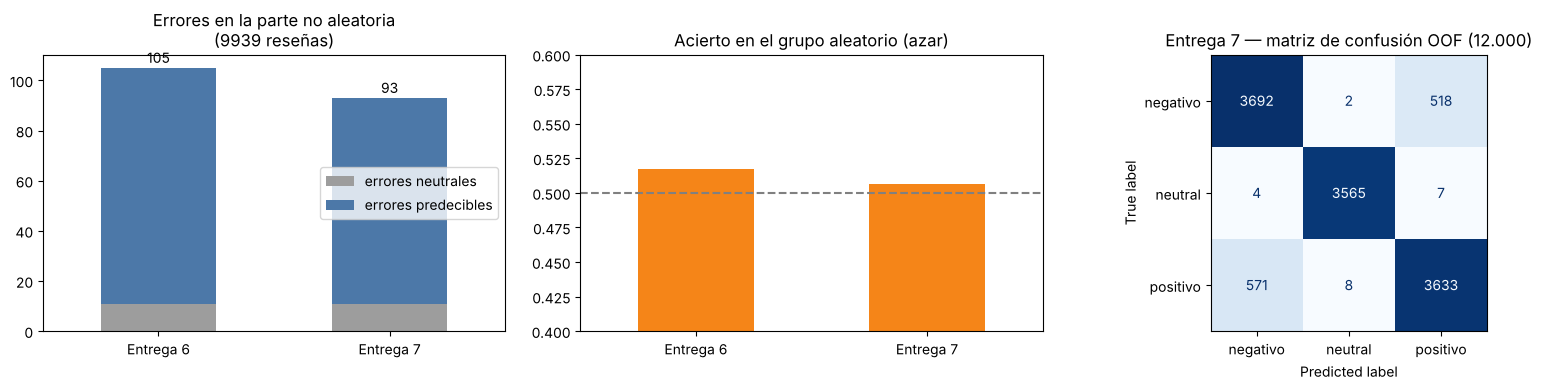

,errores neutrales,errores predecibles,acierto parte no aleatoria,acierto grupo aleatorio,accuracy global,F1 macro global
Entrega 6,11.0,94.0,0.9894,0.5172,0.9083,0.9127
Entrega 7,11.0,82.0,0.9906,0.5066,0.9075,0.9120


In [12]:
X_all, y_all = train_df["text"].reset_index(drop=True), train_df["label"].values
folds = list(StratifiedKFold(5, shuffle=True, random_state=0).split(X_all, y_all))

piezas = []
for a, b in folds:
    Xa, ya, Xb = X_all.iloc[a].reset_index(drop=True), y_all[a], X_all.iloc[b]
    cv_in = StratifiedKFold(5, shuffle=True, random_state=RANDOM_STATE)
    p = {}
    for nombre, fab in [("lr", modelo_lr), ("nb", modelo_nb), ("lrop", modelo_lr_op)]:
        p[nombre] = (cross_val_predict(fab(), Xa, ya, cv=cv_in, method="predict_proba"), fab().fit(Xa, ya).predict_proba(Xb))
    pol = PolaridadClausulas2(random_state=RANDOM_STATE)
    p["pol"] = (pol.fit_transform(Xa, ya), pol.transform(Xb))
    piezas.append(p)

def oof(bloques):
    pred = np.empty(len(y_all), dtype=object)
    for (a, b), p in zip(folds, piezas):
        A = np.hstack([p[k][0] for k in bloques]); B = np.hstack([p[k][1] for k in bloques])
        pred[b] = RandomForestClassifier(500, min_samples_leaf=3, n_jobs=-1, random_state=RANDOM_STATE).fit(A, y_all[a]).predict(B)
    return pred

oof_e6, oof_e7 = oof(["pol", "lr", "nb"]), oof(["pol", "lr", "nb", "lrop"])
filas = {}
for nombre, p in [("Entrega 6", oof_e6), ("Entrega 7", oof_e7)]:
    ok = p == y_all
    filas[nombre] = {"errores neutrales": int((~ok[G_train == "neutral"]).sum()),
                     "errores predecibles": int((~ok[G_train == "predecible"]).sum()),
                     "acierto parte no aleatoria": ok[G_train != "aleatorio"].mean(),
                     "acierto grupo aleatorio": ok[G_train == "aleatorio"].mean(),
                     "accuracy global": ok.mean(), "F1 macro global": f1_score(y_all, p, average="macro")}
res_cv = pd.DataFrame(filas).T

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
res_cv[["errores neutrales", "errores predecibles"]].plot(kind="bar", stacked=True, rot=0, ax=axes[0], color=["#9D9D9D", "#4C78A8"])
axes[0].set_title(f"Errores en la parte no aleatoria\n({(G_train != 'aleatorio').sum()} reseñas)")
for i, v in enumerate(res_cv[["errores neutrales", "errores predecibles"]].sum(1)):
    axes[0].text(i, v + 2, str(int(v)), ha="center")
res_cv["acierto grupo aleatorio"].plot(kind="bar", rot=0, ax=axes[1], color="#F58518", ylim=(0.4, 0.6))
axes[1].axhline(0.5, ls="--", color="gray"); axes[1].set_title("Acierto en el grupo aleatorio (azar)")
ConfusionMatrixDisplay.from_predictions(y_all, oof_e7, labels=ORDER, cmap="Blues", ax=axes[2], colorbar=False)
axes[2].set_title("Entrega 7 — matriz de confusión OOF (12.000)")
plt.tight_layout(); plt.show()
res_cv.round(4)

**Qué sale:**
- En la parte **no aleatoria**, la entrega 7 comete **menos errores** que la 6, y el acierto en esa parte pasa del 98.9 % al 99 %. La mejora viene de la vista de opiniones.
- En el **grupo aleatorio** ambos rondan el 50 %; la diferencia entre ellos es suerte.
- La matriz de confusión muestra que casi todos los errores restantes son confusiones entre `positivo` y `negativo`, que es donde vive el grupo aleatorio.
- La **accuracy global** se mueve poco y en cualquier dirección: la domina el azar del grupo aleatorio.

## 6. ¿Qué puntaje esperar en Kaggle?

Simulamos el *leaderboard* público:
- tomamos al azar un subconjunto de `eval.csv`, del 30 % o del 50 %, porque Kaggle no publica el tamaño;
- respetamos la proporción de reseñas aleatorias que medimos en eval;
- en las reseñas aleatorias el modelo acierta con probabilidad 0.5, y en el resto con el acierto OOF de la entrega 7 en la parte no aleatoria.

La simulación usa accuracy. En este problema el F1 macro da prácticamente el mismo valor.

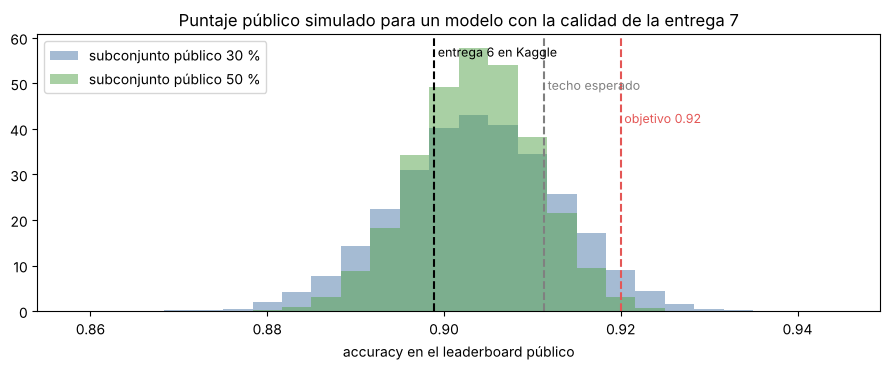

,media,desviación estándar,P(≥ 0.90),P(≥ 0.91),P(≥ 0.92)
público 30 %,0.904,0.009,0.683,0.270,0.040
público 50 %,0.904,0.007,0.722,0.187,0.008


In [13]:
rng = np.random.default_rng(RANDOM_STATE)
p_resto = res_cv.loc["Entrega 7", "acierto parte no aleatoria"]
es_al = G_eval == "aleatorio"
fig, ax = plt.subplots(figsize=(9, 3.8))
resumen_sim = {}
for frac, color in [(0.3, "#4C78A8"), (0.5, "#54A24B")]:
    n = int(frac * len(eval_df)); sims = []
    for _ in range(20000):
        idx = rng.choice(len(eval_df), n, replace=False)
        n_al = es_al[idx].sum()
        sims.append((rng.binomial(n_al, 0.5) + rng.binomial(n - n_al, p_resto)) / n)
    sims = np.array(sims)
    resumen_sim[f"público {int(frac*100)} %"] = {"media": sims.mean(), "desviación estándar": sims.std(), "P(≥ 0.90)": (sims >= 0.90).mean(),
                                                 "P(≥ 0.91)": (sims >= 0.91).mean(), "P(≥ 0.92)": (sims >= 0.92).mean()}
    ax.hist(sims, bins=np.arange(0.86, 0.95, 1 / 300) - 1 / 600, alpha=0.5, density=True, color=color,
            label=f"subconjunto público {int(frac*100)} %")   # ancho 1/300: múltiplo exacto de 1/900 y 1/1500
for (x, txt, c), h in zip([(0.8989, "entrega 6 en Kaggle", "black"), (1 - 0.5 * frac_eval, "techo esperado", "gray"),
                           (0.92, "objetivo 0.92", "#E45756")], [0.92, 0.80, 0.68]):
    ax.axvline(x, color=c, ls="--"); ax.text(x, ax.get_ylim()[1] * h, " " + txt, color=c, fontsize=9)
ax.set_title("Puntaje público simulado para un modelo con la calidad de la entrega 7"); ax.set_xlabel("accuracy en el leaderboard público")
ax.legend(loc="upper left"); plt.tight_layout(); plt.show()
pd.DataFrame(resumen_sim).T.round(3)

**Qué sale:**
- El puntaje público esperado de un modelo como el nuestro está alrededor de **0.90**, con una dispersión de **±0.7 a ±0.9 puntos** (subconjunto del 50 % o del 30 %).
- El **0.8989** de la entrega 6 está dentro de lo esperable, así que no indica un modelo peor.
- Superar **0.92** solo ocurre en un porcentaje pequeño de las simulaciones, por pura suerte en el grupo aleatorio. Lo mismo vale para otros grupos: un 0.92 público es compatible con un modelo de la misma calidad que el nuestro.
- Lo que cuenta para la nota es el *leaderboard* **privado**. Reenviar variantes hasta que una "tenga suerte" en el público no mejora el privado.

## 7. Modelo final, submission y guardado

Entrenamos `StackingPolaridad7` con todo `train.csv`. Como control, comparamos sus predicciones de `eval.csv` con las de la entrega 6 y miramos **en qué grupo** caen las diferencias.

Tamaño del modelo: 11.0 MB
Predicciones distintas a la entrega 6: 75 de 3000
{'aleatorio': 55, 'predecible o neutral': 20}


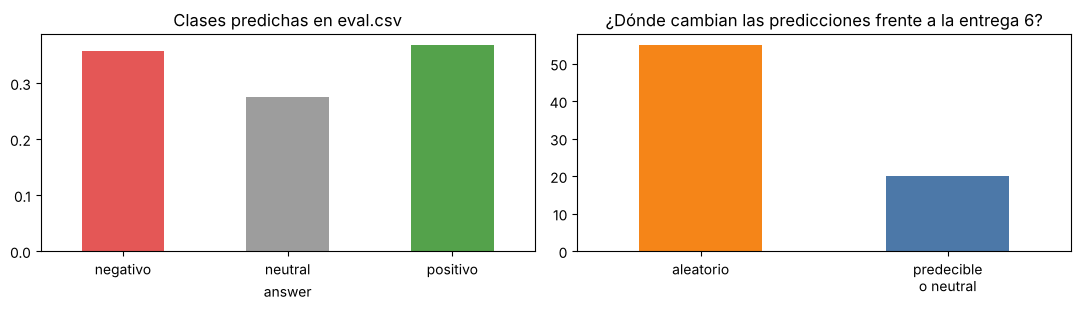

In [14]:
modelo_final = StackingPolaridad7(random_state=RANDOM_STATE).fit(train_df["text"], train_df["label"])
submission = pd.DataFrame({"id": eval_df["id"], "answer": modelo_final.predict(eval_df["text"])})
assert list(submission.columns) == list(sample_sub.columns) and submission["id"].equals(sample_sub["id"])
assert submission["answer"].isin(ORDER).all()
submission.to_csv("submission-G43-7.csv", index=False)

modelo_final.X_meta_train_ = None
joblib.dump(modelo_final, "models/modelo_entrega7_stacking.joblib", compress=3)
assert (joblib.load("models/modelo_entrega7_stacking.joblib").predict(eval_df["text"]) == submission["answer"]).all()
print(f"Tamaño del modelo: {Path('models/modelo_entrega7_stacking.joblib').stat().st_size / 1e6:.1f} MB")

sub6 = pd.read_csv("../entrega 6/submission-G43-6.csv")
distinto = sub6["answer"].values != submission["answer"].values
print(f"Predicciones distintas a la entrega 6: {distinto.sum()} de {len(eval_df)}")
print(pd.Series(np.where(es_al, "aleatorio", "predecible o neutral")[distinto]).value_counts().to_dict())

fig, axes = plt.subplots(1, 2, figsize=(11, 3.2))
submission["answer"].value_counts(normalize=True).reindex(ORDER).plot(kind="bar", rot=0, ax=axes[0], color=[COLORS[c] for c in ORDER])
axes[0].set_title("Clases predichas en eval.csv")
pd.Series(np.where(es_al, "aleatorio", "predecible\no neutral")[distinto]).value_counts().plot(kind="bar", rot=0, ax=axes[1], color=["#F58518", "#4C78A8"])
axes[1].set_title("¿Dónde cambian las predicciones frente a la entrega 6?")
plt.tight_layout(); plt.show()

**Qué sale:**
- La distribución predicha (≈ 36/28/36) es cercana a la de entrenamiento (35/30/35) y el modelo se recarga con predicciones idénticas.
- La mayoría de las predicciones que cambian frente a la entrega 6 están en el **grupo aleatorio**, donde cambiar de respuesta no mejora ni empeora en promedio. Por eso es esperable que el puntaje público de esta entrega quede cerca del de la 6 y que se mueva en cualquier dirección.

**Para cargar el `.joblib`** hay que ejecutar antes las secciones 1, 3 y 4, que definen las funciones y clases que usa el modelo.

## 8. Conclusiones

1. **El techo esperado en `eval.csv` es ≈ 0.911.** El 17.8 % de las reseñas son mixtas con frases hechas y su etiqueta no depende del texto. Lo verificamos con cinco métodos distintos, todos alrededor del 50 %.
2. **El modelo está a ≈ 1 punto de ese techo** y casi todo ese punto se explica por el grupo aleatorio. En la parte predecible acierta ≈ 99 %. La vista "última cláusula con opinión" redujo esos errores en ≈ 11 %, pero el margen restante en esa parte es de décimas de punto.
3. **Pasar 0.90 en el público depende sobre todo de la suerte de la partición**, y 0.92 es improbable para cualquier modelo. La decisión importante no es perseguir el público, sino entregar en Bloque Neón un modelo cuya calidad esté demostrada con validación cruzada. Esta entrega (o la 6) cumple eso.
4. **Para la sustentación:** el grupo puede explicar con datos por qué su puntaje está donde está, cuál es el techo y por qué los modelos de la Parte 1 (y probablemente los de la Parte 2) no pueden superarlo.